# 03 — Explore data quality

Inspect a few contrasting sensors before designing the cleaning rule: PM2.5 distribution (negatives, impossible highs), A/B channel agreement (the fault signal), time gaps, and temperature/humidity completeness. Saves the histogram and A/B-agreement figures used later.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # so `from src...` works from notebooks/
from src.config import *
import pandas as pd
import matplotlib.pyplot as plt

# contrasting sensors: SL001 healthy/long, SL026 mid, SL030 sparse
samples = ["SL001_Sunnyview_Terrace", "SL026", "SL030"]

dfs = {}
for s in samples:
    dfs[s] = pd.read_parquet(PROCESSED / f"{s}.parquet")
    print(f"{s}: {len(dfs[s]):,} rows, "
          f"{dfs[s][DATE_COL].min()} -> {dfs[s][DATE_COL].max()}")

SL001_Sunnyview_Terrace: 1,038,078 rows, 2022-03-07 18:37:08+00:00 -> 2026-02-19 18:57:20+00:00
SL026: 937,021 rows, 2022-03-25 14:31:32+00:00 -> 2026-07-05 23:58:09+00:00
SL030: 12,491 rows, 2022-03-25 14:40:07+00:00 -> 2023-04-08 23:50:21+00:00


### PM2.5 distribution: negatives and impossible highs

In [2]:
for s, df in dfs.items():
    a = df[PM_A]
    print(f"\n=== {s} ===")
    print(f"  min: {a.min():.1f}   max: {a.max():.1f}   median: {a.median():.1f}")
    print(f"  negatives: {(a < 0).sum():,}")
    print(f"  exactly zero: {(a == 0).sum():,}")
    print(f"  above 500 (suspicious): {(a > 500).sum():,}")
    print(f"  NaN: {a.isna().sum():,}")


=== SL001_Sunnyview_Terrace ===
  min: 0.0   max: 3402.1   median: 2.9
  negatives: 0
  exactly zero: 323,439
  above 500 (suspicious): 173,246
  NaN: 0

=== SL026 ===
  min: 0.0   max: 409.5   median: 1.9
  negatives: 0
  exactly zero: 287,280
  above 500 (suspicious): 0
  NaN: 0

=== SL030 ===
  min: 0.0   max: 72.6   median: 0.1
  negatives: 0
  exactly zero: 6,048
  above 500 (suspicious): 0
  NaN: 0


### Histogram of PM2.5 (clipped at 100 so outliers don't hide the shape)

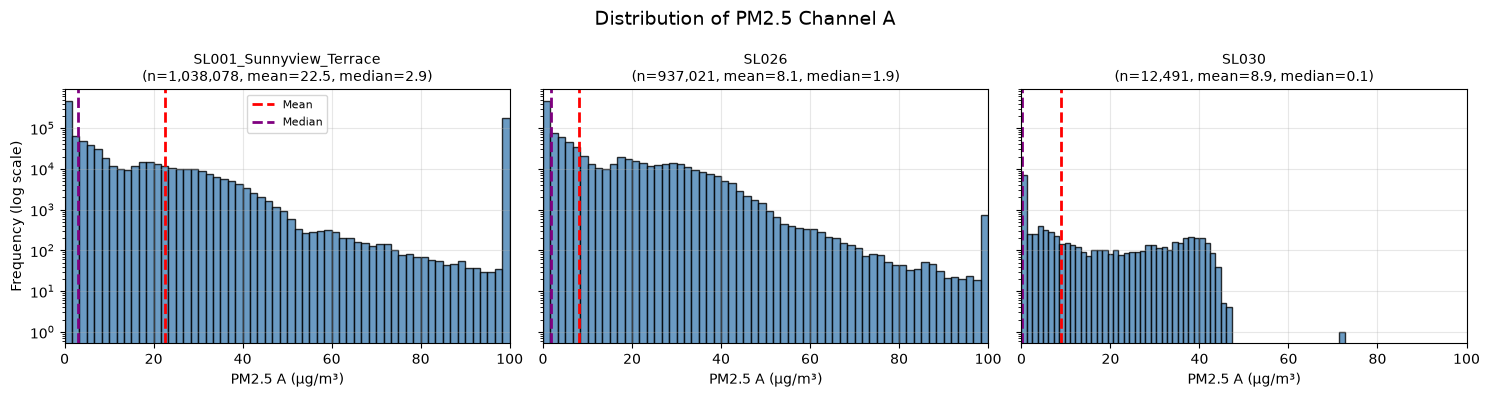

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, len(samples), figsize=(15, 4), sharey=True)

for ax, (s, df) in zip(axes, dfs.items()):

    values = df[PM_A].clip(0, 100)

    ax.hist(
        values,
        bins=60,
        color="steelblue",
        edgecolor="black",
        alpha=0.8
    )

    ax.axvline(values.mean(),
               color="red",
               linestyle="--",
               linewidth=2,
               label="Mean")

    ax.axvline(values.median(),
               color="purple",
               linestyle="--",
               linewidth=2,
               label="Median")

    ax.set_yscale("log")

    ax.set_xlim(0, 100)

    ax.set_title(f"{s}\n(n={len(values):,}, mean={values.mean():.1f}, median={values.median():.1f})", fontsize=10)

    ax.set_xlabel("PM2.5 A (µg/m³)")

    ax.grid(alpha=0.3)

axes[0].set_ylabel("Frequency (log scale)")
axes[0].legend(fontsize=8)

fig.suptitle("Distribution of PM2.5 Channel A", fontsize=14)

plt.tight_layout()

plt.savefig(
    OUT_FIGURES / "pm25_histograms_improved.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### A vs B channel agreement — the fault signal
A healthy sensor's points hug the diagonal; a faulty one sprays off it.

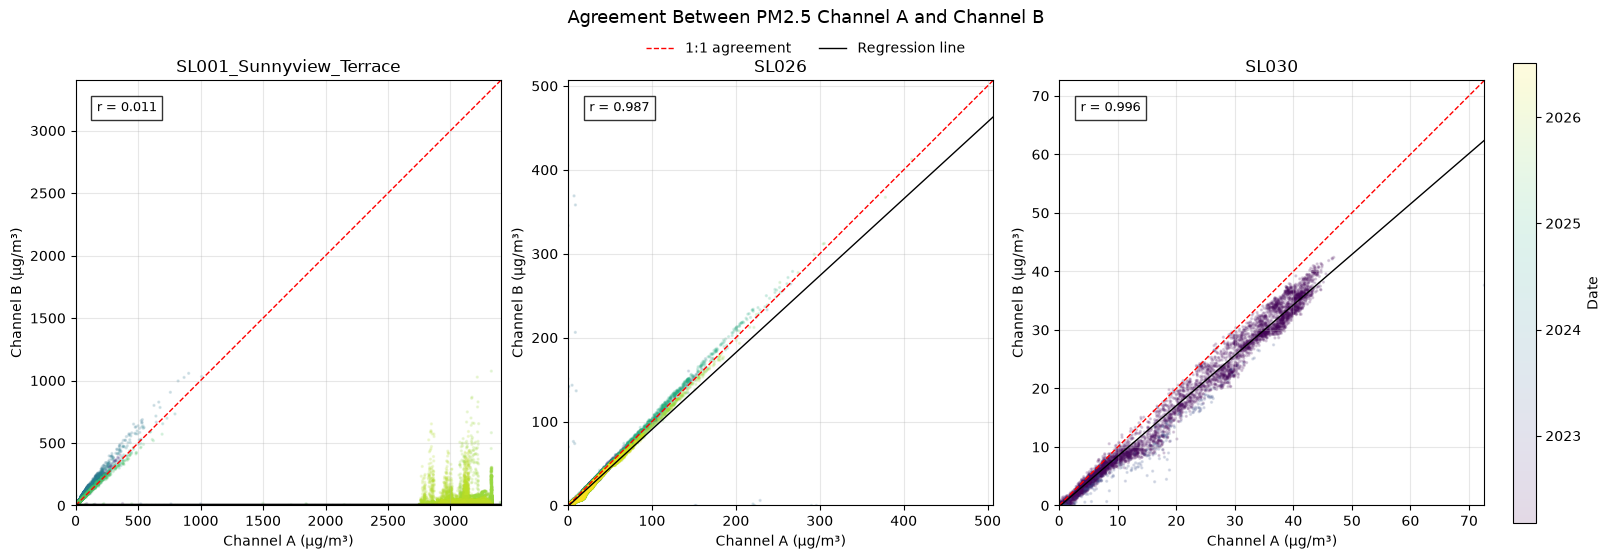

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

fig, axes = plt.subplots(
    1, len(samples),
    figsize=(16, 5),
    constrained_layout=True
)

allmin = min(df[DATE_COL].min() for df in dfs.values())
allmax = max(df[DATE_COL].max() for df in dfs.values())

vmin = mdates.date2num(allmin)
vmax = mdates.date2num(allmax)

for ax, (s, df) in zip(axes, dfs.items()):

    sub = df[[DATE_COL, PM_A, PM_B]].dropna()

    sc = ax.scatter(
        sub[PM_A],
        sub[PM_B],
        c=mdates.date2num(sub[DATE_COL]),
        cmap="viridis",
        s=2,
        alpha=0.15,
        vmin=vmin,
        vmax=vmax
    )

    hi = max(sub[PM_A].max(), sub[PM_B].max())

    # 1:1 line
    line1 = ax.plot([0, hi], [0, hi], "r--", lw=1)

    # regression line
    slope, intercept = np.polyfit(sub[PM_A], sub[PM_B], 1)
    x = np.linspace(0, hi, 100)
    line2 = ax.plot(x, slope * x + intercept, color="black", lw=1)

    r = sub[[PM_A, PM_B]].corr().iloc[0, 1]

    ax.text(
        0.05,
        0.95,
        f"r = {r:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    ax.set_xlim(0, hi)
    ax.set_ylim(0, hi)
    ax.set_aspect("equal")

    ax.set_title(s)
    ax.set_xlabel("Channel A (µg/m³)")
    ax.set_ylabel("Channel B (µg/m³)")
    ax.grid(alpha=0.3)

# ---------------------------
# GLOBAL LEGEND (TOP CENTER)
# ---------------------------
handles = [
    plt.Line2D([0], [0], color="red", linestyle="--", lw=1, label="1:1 agreement"),
    plt.Line2D([0], [0], color="black", lw=1, label="Regression line")
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.05)
)

# Colorbar
cbar = fig.colorbar(sc, ax=axes, pad=0.02)
cbar.set_label("Date")
cbar.ax.yaxis.set_major_locator(mdates.YearLocator())
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Agreement Between PM2.5 Channel A and Channel B", fontsize=13, y=1.09)

plt.savefig(
    OUT_FIGURES / "channel_AB_agreement_improved.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Boxplot Comparison of Sensors

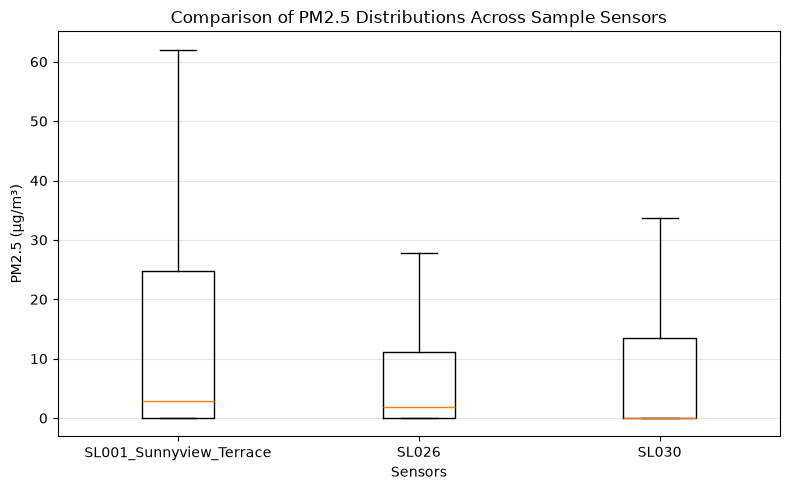

In [12]:
fig, ax = plt.subplots(figsize=(8,5))

data = [df[PM_A].clip(0,100).dropna() for df in dfs.values()]

ax.boxplot(
    data,
    tick_labels=list(dfs.keys()),
    showfliers=False
)
ax.set_xlabel("Sensors")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Comparison of PM2.5 Distributions Across Sample Sensors")


plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUT_FIGURES / "sensor_boxplots.png",
    dpi=300
)

plt.show()

### Time Series

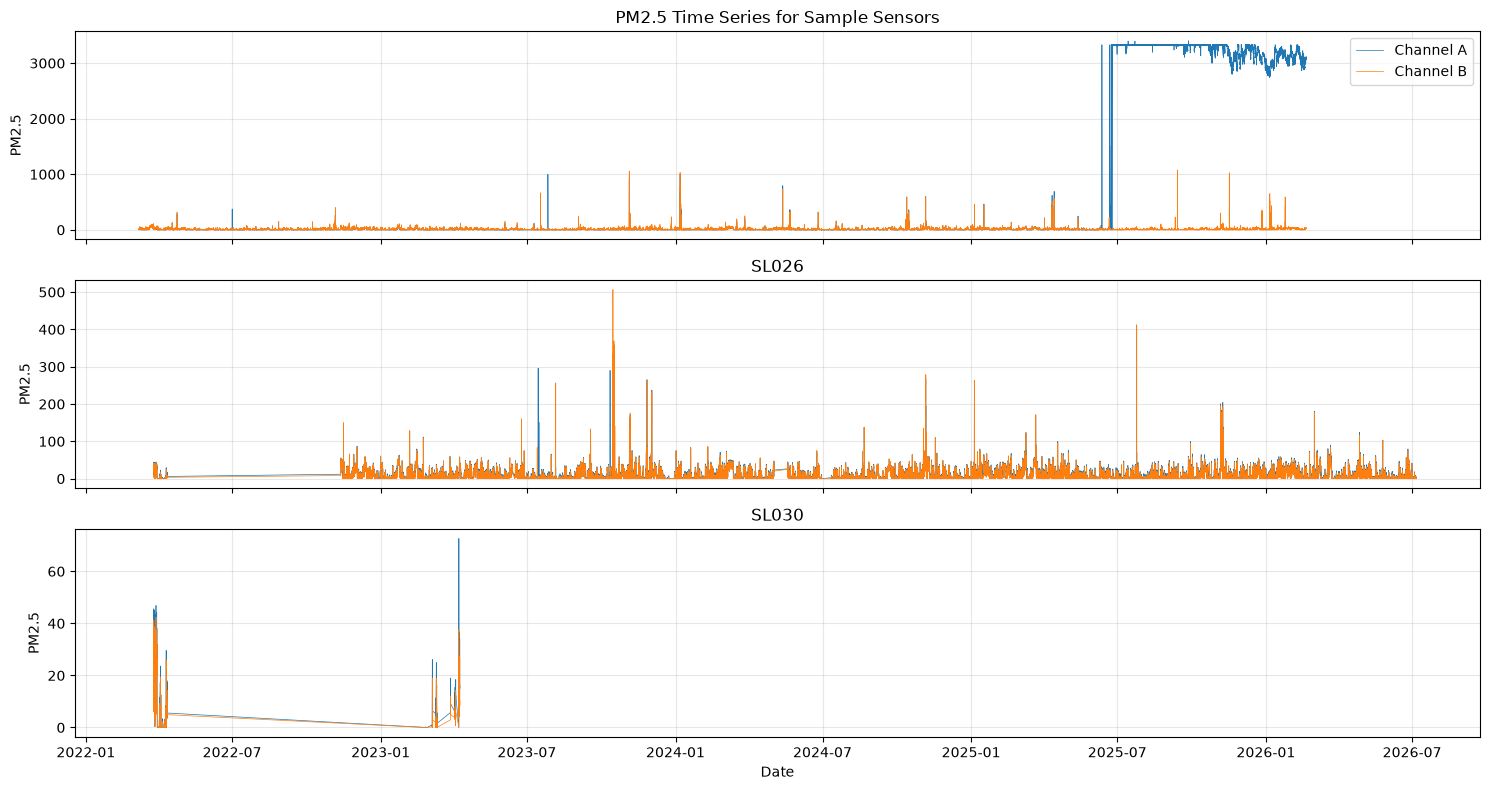

In [13]:
fig, axes = plt.subplots(len(samples), 1, figsize=(15,8), sharex=True)

if len(samples) == 1:
    axes = [axes]

for ax, (s, df) in zip(axes, dfs.items()):

    sub = df.sort_values(DATE_COL)

    ax.plot(
        sub[DATE_COL],
        sub[PM_A],
        linewidth=0.5,
        label="Channel A"
    )

    ax.plot(
        sub[DATE_COL],
        sub[PM_B],
        linewidth=0.5,
        label="Channel B"
    )

    ax.set_title(s)

    ax.set_ylabel("PM2.5")

    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")

axes[0].legend()
axes[0].set_title("PM2.5 Time Series for Sample Sensors")
plt.tight_layout()

plt.savefig(
    OUT_FIGURES / "timeseries_AB.png",
    dpi=300
)

plt.show()

### Time gaps between readings

In [8]:
for s, df in dfs.items():
    gaps = df[DATE_COL].diff().dt.total_seconds() / 60   # minutes
    print(f"\n=== {s} ===")
    print(f"  median gap: {gaps.median():.1f} min  (expected ~2)")
    print(f"  gaps > 10 min: {(gaps > 10).sum():,}")
    print(f"  gaps > 1 day: {(gaps > 1440).sum():,}  (offline stretches)")


=== SL001_Sunnyview_Terrace ===
  median gap: 2.0 min  (expected ~2)
  gaps > 10 min: 61
  gaps > 1 day: 1  (offline stretches)

=== SL026 ===
  median gap: 2.0 min  (expected ~2)
  gaps > 10 min: 174
  gaps > 1 day: 5  (offline stretches)

=== SL030 ===
  median gap: 2.0 min  (expected ~2)
  gaps > 10 min: 118
  gaps > 1 day: 7  (offline stretches)


### Temperature & humidity completeness
Relevant because the humidity correction (next stage) needs RH present.

In [9]:
for s, df in dfs.items():
    print(f"{s}: Temp missing {df[TEMP_COL].isna().mean()*100:.1f}%, "
          f"Humidity missing {df[RH_COL].isna().mean()*100:.1f}%")

SL001_Sunnyview_Terrace: Temp missing 23.5%, Humidity missing 23.5%
SL026: Temp missing 0.0%, Humidity missing 0.0%
SL030: Temp missing 0.0%, Humidity missing 0.0%
